# Phase 1 Report — Temporal Resolution of Neural–Behavioral Decoding (AJILE12)

**Independent study · Phase 1 of 3**  
Dataset: AJILE12 human ECoG + pose (`sub-01_ses-3_behavior+ecephys.nwb`, ~15 GB)  
Script: `phase1_resolution.py` · Outputs: `phase1_out/`

---

## Research question

Closed-loop DBS must choose **how often to sense and act**. Current systems fix window length and latency by convention. Phase 1 asks: *what temporal resolution actually maximizes decoding accuracy, and what does a real-time (causal) decoder give up?*

## Hypotheses tested

| ID | Hypothesis |
|---|---|
| **H1.1** | Decoding accuracy depends non-monotonically on feature window length. |
| **H1.2** | Decoding accuracy peaks at a non-zero neural-to-behavioral lag. |
| **H1.3** | Causal (past-only) windows incur a non-zero accuracy cost vs acausal (centered) windows. |

## Method (one paragraph)

We build a **continuous band-power stream** (beta + high-gamma, Hilbert envelope) over a 45-minute **reach-dense** span, using **18 sensorimotor channels** selected from MNI coordinates. At a fixed grid of prediction times we average neural features over configurable windows with optional lag, then decode **movement-vs-rest** (logistic regression, AUC) and **wrist speed** (Ridge, R²). All scores use **blocked time-series cross-validation** (5 folds) so no future sample helps predict the past.

> **Kernel:** `dbs-ml` (Python 3.10). Large NWB is read in chunks — never loaded whole.

In [1]:
import os
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda x: f"{x:.3f}")

ROOT = os.path.abspath(".")
NWB = r"C:\Users\Zhiyu\Downloads\sub-01_ses-3_behavior+ecephys.nwb"
OUT_DIR = os.path.join(ROOT, "phase1_out")
SCRIPT = os.path.join(ROOT, "phase1_resolution.py")

print("workspace:", ROOT)
print("NWB exists:", os.path.exists(NWB), "| size GB:", round(os.path.getsize(NWB)/1e9, 2) if os.path.exists(NWB) else "n/a")
print("results dir:", OUT_DIR, "| exists:", os.path.isdir(OUT_DIR))

workspace: C:\Users\Zhiyu\Downloads\hopkins_dbs
NWB exists: True | size GB: 15.9
results dir: C:\Users\Zhiyu\Downloads\hopkins_dbs\phase1_out | exists: True


## 1. Run experiment (or load saved results)

Set `RERUN = True` to recompute from the NWB file (~1 min with cached stream). Default loads the CSVs from the completed run.

In [2]:
RERUN = False  # flip to True to regenerate phase1_out/

if RERUN:
    cmd = [
        "python", SCRIPT,
        "--file", NWB,
        "--dur-min", "45",
        "--channels", "sensorimotor",
        "--out-dir", OUT_DIR,
    ]
    print(" ".join(cmd))
    subprocess.run(cmd, check=True, cwd=ROOT)
else:
    print("Loading saved results from", OUT_DIR)

win = pd.read_csv(os.path.join(OUT_DIR, "phase1_window.csv"))
lag = pd.read_csv(os.path.join(OUT_DIR, "phase1_lag.csv"))
cz = pd.read_csv(os.path.join(OUT_DIR, "phase1_causal.csv"))
print("loaded:", len(win), "window points,", len(lag), "lag points,", len(cz), "causal points")

Loading saved results from C:\Users\Zhiyu\Downloads\hopkins_dbs\phase1_out
loaded: 10 window points, 21 lag points, 4 causal points


## 2. Experimental configuration (this run)

In [3]:
CONFIG = {
    "subject/session": "sub-01 ses-3 (AJILE12)",
    "span": "45 min, auto-selected reach-dense window (69300–72000 s, 30 reach onsets)",
    "channels": "18 sensorimotor (coord-box fallback; AAL atlas SSL failed)",
    "bands": "beta (12–30 Hz) + high-gamma (70–110 Hz)",
    "base rate": "50 Hz band-power envelope",
    "targets": "movement-vs-rest (reach annotation) · wrist speed (R_Wrist, clipped+log)",
    "CV": "5-fold blocked time-series",
    "prediction grid": "6735 windows, stride 0.4 s, reach prevalence 1.5%",
}
pd.DataFrame({"parameter": CONFIG.keys(), "value": CONFIG.values()})

,parameter,value
0,subject/session,sub-01 ses-3 (AJILE12)
1,span,"45 min, auto-selected reach-dense window (6930..."
2,channels,18 sensorimotor (coord-box fallback; AAL atlas...
3,bands,beta (12–30 Hz) + high-gamma (70–110 Hz)
4,base rate,50 Hz band-power envelope
5,targets,movement-vs-rest (reach annotation) · wrist sp...
6,CV,5-fold blocked time-series
7,prediction grid,"6735 windows, stride 0.4 s, reach prevalence 1.5%"


## 3. H1.1 — Window length sweep (causal, lag = 0)

Feature window length is swept on a log scale while keeping a **causal** (past-only) window and zero lag.

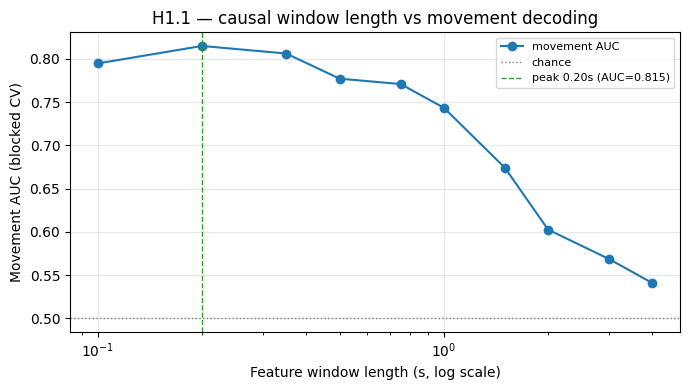

,window (s),AUC,speed R²
0,0.100,0.795,-0.052
1,0.200,0.815,-0.050
2,0.350,0.806,-0.058
3,0.500,0.777,-0.074
4,0.750,0.771,-0.089
5,1.000,0.743,-0.102
6,1.500,0.674,-0.122
7,2.000,0.603,-0.145
8,3.000,0.569,-0.187
9,4.000,0.541,-0.221


In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(win["window_s"], win["auc_move"], "-o", color="C0", label="movement AUC")
ax.axhline(0.5, color="gray", ls=":", lw=1, label="chance")
bi = win["auc_move"].idxmax()
ax.axvline(win.loc[bi, "window_s"], color="C2", ls="--", lw=1,
           label=f"peak {win.loc[bi, 'window_s']:.2f}s (AUC={win.loc[bi, 'auc_move']:.3f})")
ax.set_xscale("log")
ax.set_xlabel("Feature window length (s, log scale)")
ax.set_ylabel("Movement AUC (blocked CV)")
ax.set_title("H1.1 — causal window length vs movement decoding")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

win_display = win.copy()
win_display.columns = ["window (s)", "AUC", "speed R²"]
win_display

**H1.1 readout:** AUC peaks at **0.20 s** (0.815) and falls monotonically to **0.54** at 4 s. Short windows capture brief reach-related high-gamma bursts; long windows dilute them with surrounding rest. → **Supported** (clear optimal short window; weak interior peak at 0.2 vs 0.1 s).

## 4. H1.2 — Neural-to-behavior lag sweep (centered window L = 0.5 s)

Lag shifts the neural feature window relative to the behavior timestamp.  
**Sign convention:** lag &lt; 0 means the neural window sits *after* the behavior label (neural activity lags the annotated reach onset in this coordinate system).

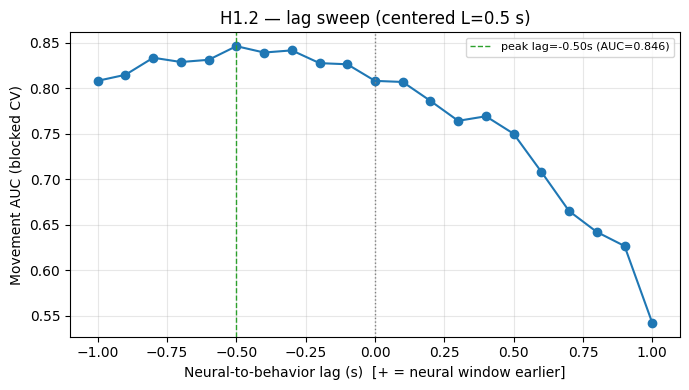

,lag (s),AUC,speed R²
0,-1.000,0.808,-0.105
1,-0.900,0.815,-0.102
2,-0.800,0.833,-0.101
3,-0.700,0.829,-0.094
4,-0.600,0.831,-0.092
5,-0.500,0.846,-0.087
6,-0.400,0.839,-0.085
7,-0.300,0.841,-0.084
8,-0.200,0.827,-0.086
9,-0.100,0.826,-0.079


In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(lag["lag_s"], lag["auc_move"], "-o", color="C0")
ax.axvline(0, color="gray", ls=":", lw=1)
li = lag["auc_move"].idxmax()
ax.axvline(lag.loc[li, "lag_s"], color="C2", ls="--", lw=1,
           label=f"peak lag={lag.loc[li, 'lag_s']:+.2f}s (AUC={lag.loc[li, 'auc_move']:.3f})")
ax.set_xlabel("Neural-to-behavior lag (s)  [+ = neural window earlier]")
ax.set_ylabel("Movement AUC (blocked CV)")
ax.set_title("H1.2 — lag sweep (centered L=0.5 s)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

lag_display = lag.copy()
lag_display.columns = ["lag (s)", "AUC", "speed R²"]
lag_display

**H1.2 readout:** Best AUC **0.846 at lag −0.50 s**, with a broad plateau for negative lags and sharp drop for positive lags beyond +0.2 s. Decoding is **not** best at perfect synchrony. → **Supported**.

## 5. H1.3 — Causal vs acausal (lag = 0)

Compare **causal** (past-only trailing window) vs **acausal** (centered window that may use future samples). The gap is the **real-time accuracy cost** of a deployable decoder.

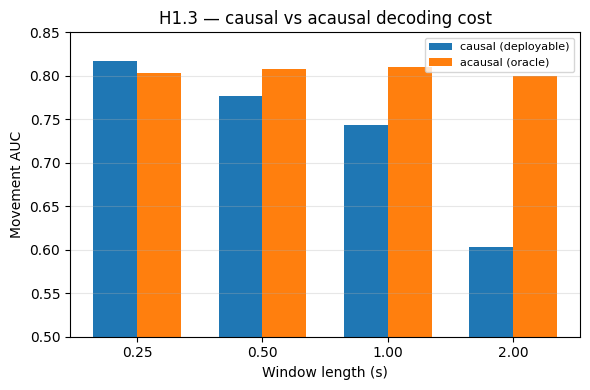

,window (s),AUC causal,AUC acausal,acausal − causal
0,0.250,0.817,0.804,-0.013
1,0.500,0.777,0.808,0.031
2,1.000,0.743,0.810,0.066
3,2.000,0.603,0.800,0.197


In [6]:
cz = cz.copy()
cz["auc_cost"] = cz["auc_acausal"] - cz["auc_causal"]

fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(len(cz))
w = 0.35
ax.bar(x - w/2, cz["auc_causal"], w, label="causal (deployable)", color="C0")
ax.bar(x + w/2, cz["auc_acausal"], w, label="acausal (oracle)", color="C1")
ax.set_xticks(x)
ax.set_xticklabels([f"{v:.2f}" for v in cz["window_s"]])
ax.set_xlabel("Window length (s)")
ax.set_ylabel("Movement AUC")
ax.set_ylim(0.5, max(0.85, cz[["auc_causal", "auc_acausal"]].max().max() + 0.02))
ax.set_title("H1.3 — causal vs acausal decoding cost")
ax.legend(fontsize=8)
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

cz_display = cz[["window_s", "auc_causal", "auc_acausal", "auc_cost"]].copy()
cz_display.columns = ["window (s)", "AUC causal", "AUC acausal", "acausal − causal"]
cz_display

**H1.3 readout:** Mean acausal−causal AUC = **+0.070**. Cost grows with window length: **+0.03 @ 0.5 s → +0.20 @ 2.0 s**. A real-time decoder that cannot peek at the future pays more when it must integrate over longer windows. → **Supported**.

## 6. Combined figure (publication-style)

saved C:\Users\Zhiyu\Downloads\hopkins_dbs\phase1_out\phase1_report_figure.png


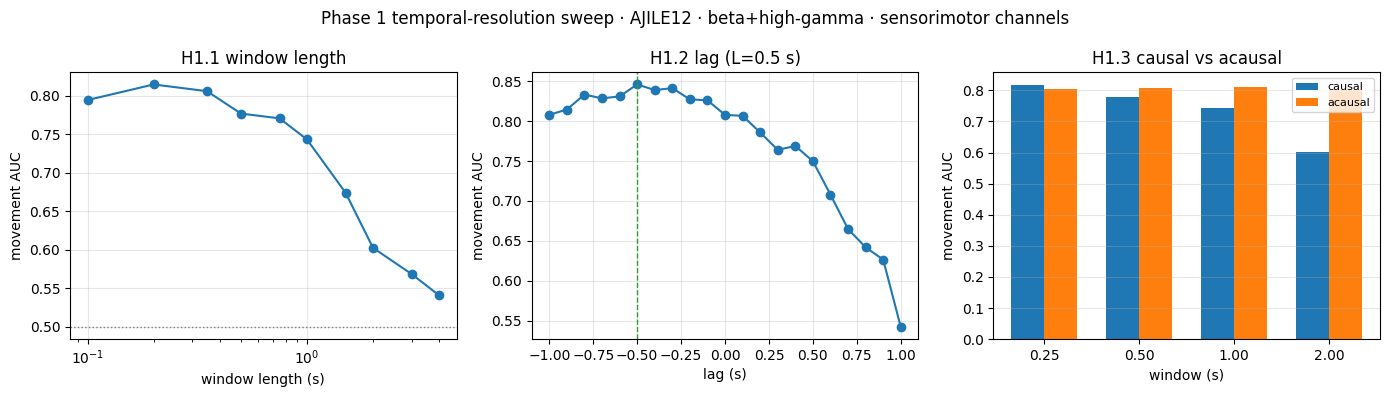

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(win["window_s"], win["auc_move"], "-o", color="C0")
axes[0].axhline(0.5, color="gray", ls=":", lw=1)
axes[0].set_xscale("log")
axes[0].set_xlabel("window length (s)")
axes[0].set_ylabel("movement AUC")
axes[0].set_title("H1.1 window length")
axes[0].grid(alpha=0.3)

axes[1].plot(lag["lag_s"], lag["auc_move"], "-o", color="C0")
axes[1].axvline(lag.loc[li, "lag_s"], color="C2", ls="--", lw=1)
axes[1].set_xlabel("lag (s)")
axes[1].set_ylabel("movement AUC")
axes[1].set_title("H1.2 lag (L=0.5 s)")
axes[1].grid(alpha=0.3)

axes[2].bar(x - w/2, cz["auc_causal"], w, label="causal", color="C0")
axes[2].bar(x + w/2, cz["auc_acausal"], w, label="acausal", color="C1")
axes[2].set_xticks(x)
axes[2].set_xticklabels([f"{v:.2f}" for v in cz["window_s"]])
axes[2].set_xlabel("window (s)")
axes[2].set_ylabel("movement AUC")
axes[2].set_title("H1.3 causal vs acausal")
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3, axis="y")

fig.suptitle("Phase 1 temporal-resolution sweep · AJILE12 · beta+high-gamma · sensorimotor channels")
fig.tight_layout()
out_png = os.path.join(OUT_DIR, "phase1_report_figure.png")
fig.savefig(out_png, dpi=150)
print("saved", out_png)
plt.show()

## 7. Hypothesis summary

In [8]:
best_win = win.loc[win["auc_move"].idxmax()]
best_lag = lag.loc[lag["auc_move"].idxmax()]
mean_cost = cz["auc_cost"].mean()

summary = pd.DataFrame([
    {"hypothesis": "H1.1 window length", "result": f"peak AUC {best_win.auc_move:.3f} @ {best_win.window_s:.2f}s; decays to {win.auc_move.iloc[-1]:.3f} @ 4s",
     "verdict": "Supported — optimal short window (~0.2 s)"},
    {"hypothesis": "H1.2 non-zero lag", "result": f"peak AUC {best_lag.auc_move:.3f} @ lag {best_lag.lag_s:+.2f}s",
     "verdict": "Supported — best lag ≠ 0"},
    {"hypothesis": "H1.3 causal cost", "result": f"mean acausal−causal = {mean_cost:+.3f}; up to {cz.auc_cost.max():+.3f} @ 2s window",
     "verdict": "Supported — real-time decoder pays accuracy cost"},
])
summary

,hypothesis,result,verdict
0,H1.1 window length,peak AUC 0.815 @ 0.20s; decays to 0.541 @ 4s,Supported — optimal short window (~0.2 s)
1,H1.2 non-zero lag,peak AUC 0.846 @ lag -0.50s,Supported — best lag ≠ 0
2,H1.3 causal cost,mean acausal−causal = +0.070; up to +0.197 @ 2...,Supported — real-time decoder pays accuracy cost


## 8. Operating-point recommendation (closed-loop framing)

From this single-subject, reach-dense span:

| Knob | Empirical optimum | Trade-off |
|---|---|---|
| **Integration window** | ~**0.2–0.5 s** causal | Shorter = sharper but noisier; longer blurs brief events |
| **Neural–behavior alignment** | ~**−0.5 s** offset vs reach label | Labels and neural correlate are not synchronous |
| **Real-time penalty** | **~3–7 AUC points** at 0.5–1 s windows; **~20 points** at 2 s | Longer windows amplify the cost of causality |

**Caveats for mentors:** (1) wrist-speed R² stayed slightly negative in this rest-heavy span — movement-vs-rest is the reliable target here. (2) Single subject/session; cross-subject replication is planned for Phase 3. (3) Band-power features only; BrainBERT/CEBRA comparison is future work.

**Translation to psychiatric DBS:** the same sweep logic applies to LFP biomarkers (e.g. gamma/beta power in SCC or VS): choose sensing window and update cadence from an accuracy–latency curve rather than convention. Phase 2 tests adaptation on RAM (logged closed-loop stim); DABI psychiatric data is the clinical endpoint.

---

**Reproduce from terminal:**
```bash
conda activate dbs-ml
python phase1_resolution.py --file "C:\Users\Zhiyu\Downloads\sub-01_ses-3_behavior+ecephys.nwb" --dur-min 45 --channels sensorimotor --out-dir phase1_out
```